**Step 1: Import Libraries**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, datasets
import matplotlib.pyplot as plt

**Step 2: Download and Prepare Dataset**

In [ ]:
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data(path="mnist.npz")

x_train, x_test = x_train / 255.0, x_test / 255.0

num_classes = 10
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test  = tf.keras.utils.to_categorical(y_test , num_classes)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000, 10)
(10000, 28, 28)
(10000, 10)


**Step 3: Build CNN Model**

In [ ]:
model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='tanh', padding='same', input_shape=(28,28,1)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='tanh', padding='same'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='tanh', padding='same'),
    layers.Flatten(),

    layers.Dense(64, activation='tanh'),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 257,162 (1004.54 KB)

 Trainable params: 257,162 (1004.54 KB)

 Non-trainable params: 0 (0.00 B)

**Step 4: Train the Model**

In [ ]:
model.compile(optimizer='adam',
              loss='categorical_focal_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train,
                    epochs=5,
                    batch_size=64,
                    validation_split=0.2,
                    verbose=2)

Epoch 1/5
750/750 - 75s - 99ms/step - accuracy: 0.9862 - loss: 0.0050 - val_accuracy: 0.9805 - val_loss: 0.0077
Epoch 2/5
750/750 - 71s - 95ms/step - accuracy: 0.9866 - loss: 0.0046 - val_accuracy: 0.9824 - val_loss: 0.0082
Epoch 3/5
750/750 - 71s - 95ms/step - accuracy: 0.9872 - loss: 0.0042 - val_accuracy: 0.9833 - val_loss: 0.0076
Epoch 4/5
750/750 - 82s - 109ms/step - accuracy: 0.9890 - loss: 0.0032 - val_accuracy: 0.9839 - val_loss: 0.0066
Epoch 5/5
750/750 - 71s - 95ms/step - accuracy: 0.9886 - loss: 0.0036 - val_accuracy: 0.9846 - val_loss: 0.0060


**Step 5: Evaluate the Model**

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

print(f"Test accuracy = {test_acc:.3f}")

Test accuracy = 0.988


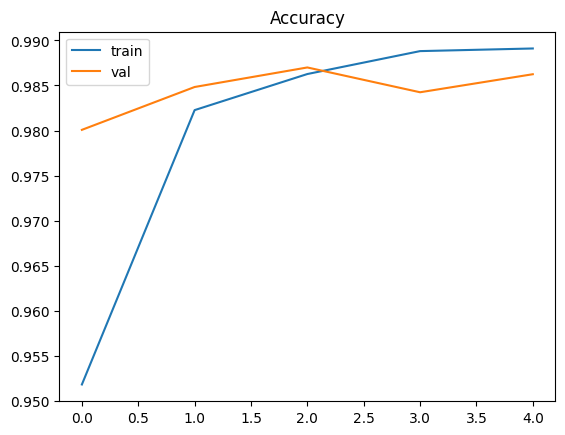

In [ ]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title('Accuracy')
plt.show()